# Lab Sheet 5

In [2]:
from header import *

Exercise 1

(a)

In [8]:
q = sp.functions.special.error_functions.li

The function is undefined for $x<0$.  It zero (and the graph is flat) at $x=0$, then it drops down to $-\infty$ at $x=1$, then climbs back to zero at about $x=1.4$, and increases thereafter towards $\infty$.


<Axes: >

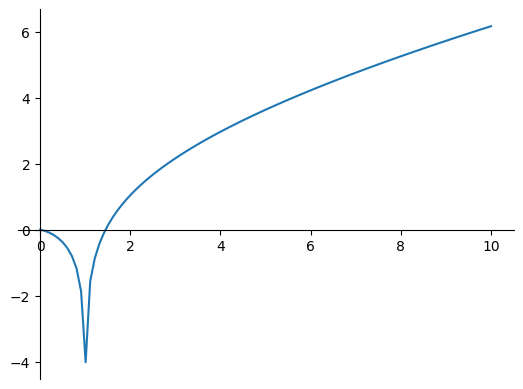

In [9]:
x = np.linspace(0,10,100)
y = [q(x0) for x0 in x]
plt.plot(x,y)
fix_axes(plt.gca())



(b) When $x<0$, the function $q'(x)$ is undefined (because $q(x)$ is).  We have $q'(0)=0$, and then $q'(x)<0$ for $0<x<1$ (because the graph is sloping downwards).  The derivative is undefined again when $x=1$, but $q'(x)>0$ for $x>1$ (because the graph is sloping upwards).


(c)

In [10]:
def Q(x, h):
    return (q(x+h) - q(x))/h

In [11]:
print(Q(np.exp(2),0.01))
print(Q(np.exp(2),1e-5))
print(Q(np.exp(2),1e-10))

0.499830983358596
0.499999830783082
0.500000041370185


In [12]:
print(Q(np.exp(3),0.01))
print(Q(np.exp(3),1e-5))
print(Q(np.exp(3),1e-10))

0.333305681498786
0.333333305668759
0.333333360913457


In [13]:
print(Q(np.exp(4),0.01))
print(Q(np.exp(4),1e-5))
print(Q(np.exp(4),1e-10))

0.249994276886767
0.249999994395011
0.250004461577191


It is clear from the calculations above that $q'(e^{2})=\frac{1}{2}$ and $q'(e^{3})=\frac{1}{3}$ and $q'(e^{4})=\frac{1}{4}$.  We therefore guess that $q'(e^{t})=\frac{1}{t}$ for all 
$t$.  Moreover, given $x>0$, we can write $x=e^{t}$ with $t=\log(x)$, so $q'(x)=\frac{1}{\log(x)}$.  This means that $q(x)$ is actually the same as a standard function called the [logarithmic integral](https://en.wikipedia.org/wiki/Logarithmic_integral_function) or $\text{li}(x)$.  This is defined by 
$$ \text{li}(x)=\int_{t=0}^{x}\frac{dt}{\log(t)}. $$ 


In [14]:
del x
x, t = sp.symbols('x t')
sp.integrate(1/sp.log(t),(t,0,x)) - q(x)

0

In [15]:
del x,t

Exercise 2

(a) The roots of $f'(x)$ occur where the graph of $f(x)$ is flat, or in other words, the tangent line is horizontal.  This occurs wherever $f(x)$ has a local maximum or a local minimum (and possibly also in some other places, called inflexion points).


In [11]:
x = sp.symbols('x')

f = x**3 - x
display(Latex("$f(x) = " + sp.latex(f) + "$"))
df = sp.diff(f,x)
display(Latex("$f'(x) = " + sp.latex(df) + "$"))
f1 = sp.lambdify(x, f, 'numpy')
df1 = sp.lambdify(x, df, 'numpy')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

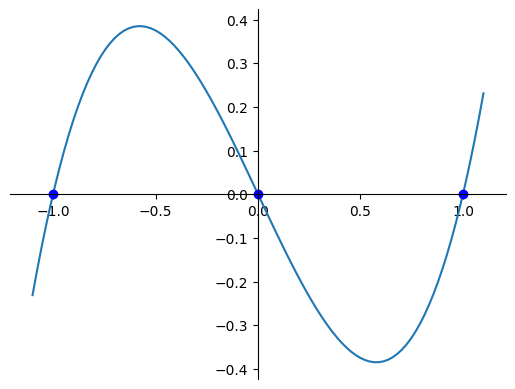

In [9]:
xs = np.linspace(-1.1,1.1,100)
ys = f1(xs)
roots = np.array([s[0] for s in sp.solve([f],[x])])
plt.plot(xs,ys)
plt.plot(roots, 0*roots, 'bo')
fix_axes(plt.gca())
display(Latex(f"Roots of $f(x)$ are {roots}"))

(b)

<IPython.core.display.Latex object>

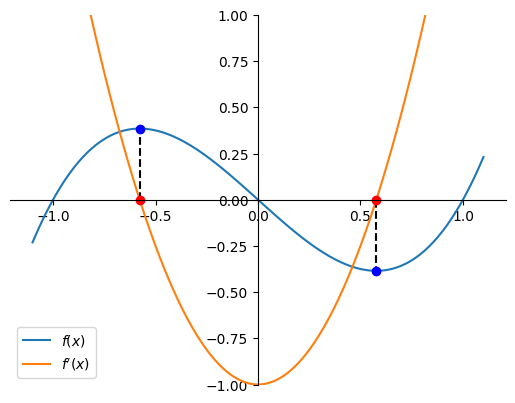

In [14]:
xs = np.linspace(-1.1,1.1,100)
ys = f1(xs)
zs = df1(xs)
roots = np.array([s[0] for s in sp.solve([df],[x])])
plt.plot(xs,ys, label="$f(x)$")
plt.plot(xs,zs, label="$f'(x)$")
for r in roots:
    plt.plot([r,r],[0,f1(r)],'k--')
    plt.plot([r],[0],'ro')
    plt.plot([r],[f1(r)],'bo')
plt.ylim(-1,1)
plt.legend()
fix_axes(plt.gca())
display(Latex(f"Roots of $f'(x)$ are ${sp.latex(roots[0])}$ and ${sp.latex(roots[1])}$"))

There are roots of $f(x)$ at $x=-1$, $x=0$ and $x=1$.  Between $x=-1$ and $x=0$ we have a root of $f'(x)$ at about $x=-0.6$, corresponding to the top of the left-hand hump.  Between $x=0$ and 
$x=1$ we have a root of $f'(x)$ at about $x=0.6$, corresponding to the top of the right-hand hump.  Thus, Rolle's principle is satisfied.

(c)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

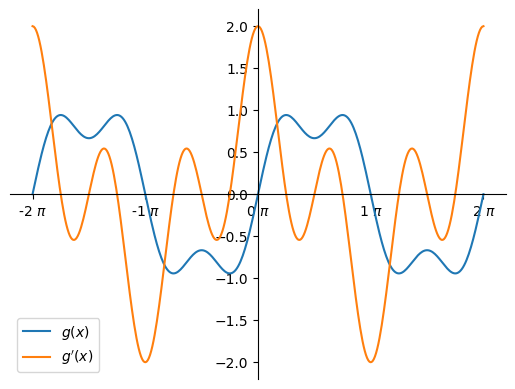

In [13]:
g = sp.sin(x) + sp.sin(3*x)/3
display(Latex("$g(x) = " + sp.latex(g) + "$"))
dg = sp.diff(g,x)
display(Latex("$g'(x) = " + sp.latex(dg) + "$"))
g1 = sp.lambdify(x, g, 'numpy')
dg1 = sp.lambdify(x, dg, 'numpy')
xs = np.linspace(-2*np.pi,2*np.pi,400)
ys = g1(xs)
zs = dg1(xs)
fig, ax = plt.subplots()
ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%g $\pi$'))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=1))
ax.plot(xs/np.pi, ys, label='$g(x)$')
ax.plot(xs/np.pi, zs, label="$g'(x)$")
ax.legend()
fix_axes(ax)
None

We can see roots of $g(x)$ at $x=-2\pi$, $-\pi$, $0$, $\pi$ and $2\pi$; in general, the roots are at $x=n\pi$ for integers $n$.  Between $x=0$ and $x=\pi$ there are two maxima and one local minimum, giving three roots of $g'(x)$.  (This is perfectly consistent with Rolle's principle, which says only that there is *at least one* root of $g'(x) $ between $0$ and $\pi$.)  Similarly, between $x=\pi$ and $x=2\pi$ there are two minima and one local maximum for $g(x)$, corresponding to the three places where the graph of $g'(x)$ (in orange) crosses the $x$-axis.  We can find the location of the these roots as follows:


In [17]:
sp.solveset(dg)

Union(ImageSet(Lambda(_n, 2*_n*pi + pi/2), Integers), ImageSet(Lambda(_n, 2*_n*pi + 3*pi/2), Integers), ImageSet(Lambda(_n, 2*_n*pi + 5*pi/4), Integers), ImageSet(Lambda(_n, 2*_n*pi + 3*pi/4), Integers), ImageSet(Lambda(_n, 2*_n*pi + 7*pi/4), Integers), ImageSet(Lambda(_n, 2*_n*pi + pi/4), Integers))

Sympy does not give the answer in the most efficient form: it is better to say that the roots are $(n+k/4)\pi$ with $n\in\mathbb{Z}$ and $k\in\{1,2,3\}$.

(d) Suppose that $a$ and $b$ are two different roots of $f(x)$, so $f(a)=0$ and $f(b)=0$.  As $x$ moves from $a$ to $b$, the function $f(x)$ cannot increase all the time (otherwise 
$f(b)$ would be greater than 0) and it cannot decrease all the time (otherwise $f(b)$ would be less than 0).  It must increase some of the time and decrease some of the time, so there must be some point at which it changes over from increasing to decreasing (or vice-versa), and at that point we will have $f'(x)=0$.


(e) As we see in the plot below, the roots of $h(x)=\tan(x)$ are at $x=n\pi$ for integers $n$.


<IPython.core.display.Latex object>

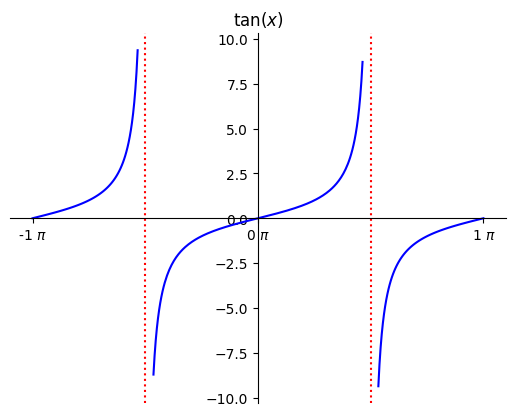

In [20]:
h = sp.tan(x)
dh = sp.diff(h,x)
display(Latex(f"The derivative of $h(x) = {sp.latex(h)}$ is $h'(x) = {sp.latex(dh)}$"))
h1 = sp.lambdify(x, h, 'numpy')
dh1 = sp.lambdify(x, dh, 'numpy')
xs = np.linspace(-np.pi,np.pi,400)
ys = h1(xs)
ix = np.abs(ys) < 10
xs = xs[ix]
ys = ys[ix]
ix0 = xs < -np.pi/2
ix1 = (-np.pi/2 < xs ) & (xs < np.pi/2)
ix2 = np.pi/2 < xs
fig, ax = plt.subplots()
ax.title.set_text(r'$\tan(x)$')
ax.plot(xs[ix0]/np.pi,ys[ix0],'b-')
ax.plot(xs[ix1]/np.pi,ys[ix1],'b-')
ax.plot(xs[ix2]/np.pi,ys[ix2],'b-')
ax.axvline(-0.5, color='r', linestyle='dotted')
ax.axvline( 0.5, color='r', linestyle='dotted')
use_pi_ticks(ax)
fix_axes(ax)
None


The graph is always sloping upwards, so $h'(x)>0$ for all $x$.  In fact, we have $h'(x)=\sec(x)^{2}=1+\tan(x)^2$, which shows that $h'(x)\geq 1$ for all $x$.  In any case, $h'(x)$ has no roots at all, contradicting Rolle's principle.  So what goes wrong in the argument that we outlined?  As $x$ moves from $0$ to $\pi$, the function increases from $0$ up towards $\infty$, then jumps down discontinuously.   When $x=\pi/2$, neither $h(x)$ nor $h'(x) $ is really well-defined.

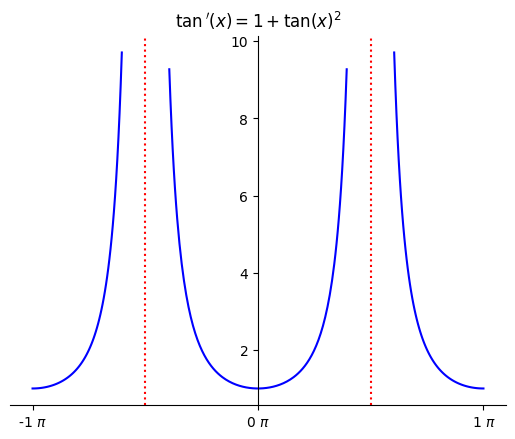

In [21]:
ys = dh1(xs)
ix = np.abs(ys) < 10
xs = xs[ix]
ys = ys[ix]
ix0 = xs < -np.pi/2
ix1 = (-np.pi/2 < xs ) & (xs < np.pi/2)
ix2 = np.pi/2 < xs
fig, ax = plt.subplots()
ax.title.set_text(r"$\tan'(x)=1+\tan(x)^2$")
ax.plot(xs[ix0]/np.pi,ys[ix0],'b-')
ax.plot(xs[ix1]/np.pi,ys[ix1],'b-')
ax.plot(xs[ix2]/np.pi,ys[ix2],'b-')
ax.axvline(-0.5, color='r', linestyle='dotted')
ax.axvline( 0.5, color='r', linestyle='dotted')
use_pi_ticks(ax)
fix_axes(ax)
None


In [22]:
del f,g,h,df,dg,dh,f1,g1,h1,df1,dg1,dh1,xs,ys,zs,ix,ix0,ix1,ix2

Exercise 3

In [19]:
x, n, a, b, c, d, p = sp.symbols('x n a b c d p')

def schwarzian(f,x):
    return f.diff(x,3)/f.diff(x) - sp.Rational(3,2) * (f.diff(x,2)/f.diff(x))**2

Put $y=x^{n}$.  Then $y'=nx^{n-1}$ and $y''=n(n-1) x^{n-2}$ and $ {y'''}=n (n-1) (n-2) x^{n-3} $.  If $n=0$ then $y'=0$, so we cannot divide by $y'$, so $S(y)$ is undefined.  For any other value of $n$, we have  $y''/y'=(n-1)/x$ and  $y'''/y'=(n-1)(n-2)/x^{2}$.  This gives
\begin{align*}
 S(y) &= \frac{{y'''}}{{y'}}-\frac{3 (\frac{{y''}}{{y'}})^{2}}{2} 
       =\frac{(n -1) (n -2)}{x^{2}}-\frac{3 (\frac{n -1}{x})^{2}}{2} \\
      &=\frac{2 (n^{2}-3 n +2)-3 (n -1)^{2}}{2 x^{2}} \\
      &=\frac{1-n^{2}}{2 x^{2}} 
\end{align*}


This is zero for $n=1$ or $n=-1$.  We can also do the calculation using sympy as follows:

In [20]:
ans = sp.simplify(schwarzian(x ** n, x))
display(ans)
display([s[0] for s in sp.solve([ans],[n])])

(1 - n**2)/(2*x**2)

[-1, 1]

In [24]:
y = (a * x + b) / (c * x + d)
y1 = sp.factor(sp.expand(y.diff(x)))
y2 = sp.factor(sp.expand(y1.diff(x)))
y3 = sp.factor(sp.expand(y2.diff(x)))
Sy = sp.simplify(schwarzian(y,x))

display(Latex(
  r"\begin{align*}" + 
  f"y &= {sp.latex(y)} \\\\" + 
  f"y' &= {sp.latex(y1)} \\\\" + 
  f"y'' &= {sp.latex(y2)} \\\\" + 
  f"y''' &= {sp.latex(y3)} \\\\" +
  f"S(y) &= {sp.latex(Sy)}" 
  r"\end{align*}"
))


<IPython.core.display.Latex object>

In [26]:
z = y.subs({x : p ** x})
Sz = sp.simplify(schwarzian(z,x))
Sz

-log(p)**2/2

In [27]:
def T(y, x):
    return sp.sqrt(sp.diff(y,x)) * sp.diff(1/sp.sqrt(sp.diff(y,x)),x,2)

In [28]:
y = x ** n
display(sp.simplify(T(y, x))) 
display(sp.simplify(schwarzian(y,x)))

(n**2 - 1)/(4*x**2)

(1 - n**2)/(2*x**2)

In [29]:
y = (a * x + b)/(c * x + d)
display(sp.simplify(T(y, x))) 
display(sp.simplify(schwarzian(y,x)))

0

0

In [30]:
y = sp.log(x)
display(sp.simplify(T(y, x))) 
display(sp.simplify(schwarzian(y,x)))

-1/(4*x**2)

1/(2*x**2)

In [31]:
u = sp.Function('u')
sp.simplify(2 * T(u(x),x) + schwarzian(u(x),x))

0

In [32]:
del x, n, a, b, c, d, p, y, y1, y2, y3, Sy, z, Sz, T, u

Exercise 4

In [23]:
x = sp.symbols('x')
y = sp.cos(-2 * sp.log(x))
dydx = sp.diff(y, x)
display(Latex(f"$y = {sp.latex(y)}$"))
display(Latex(f"$y' = {sp.latex(dydx)}$"))
f = sp.lambdify(x, y, 'numpy')
f1 = sp.lambdify(x, dydx, 'numpy')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<Axes: >

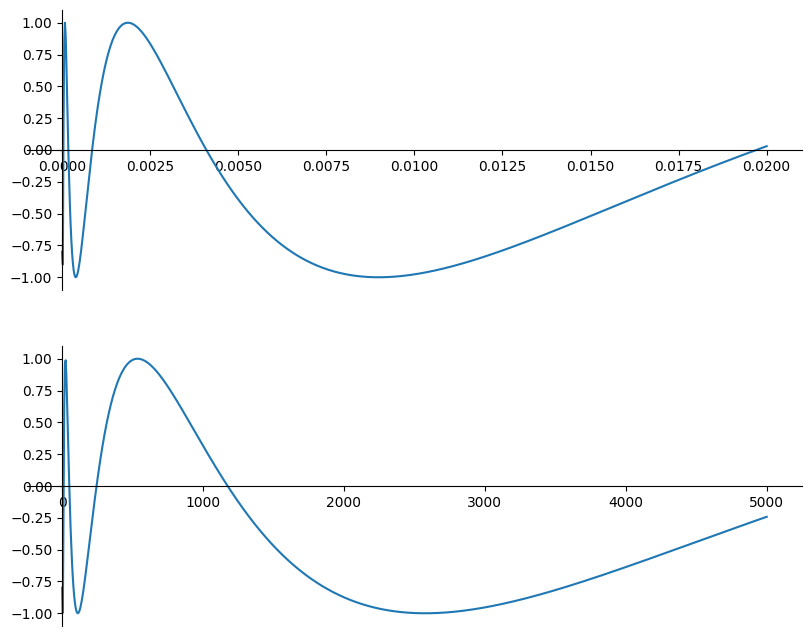

In [22]:
fig, ax = plt.subplots(2,1,figsize=(10,8))
xs = np.linspace(1e-6,0.02,1000)
ax[0].plot(xs, f(xs))
fix_axes(ax[0])
xs = np.linspace(1e-6,5000,1000)
ax[1].plot(xs, f(xs))
fix_axes(ax[1])

In [35]:
ks = np.arange(10)
a = np.exp((1/4 - ks/2) * np.pi)
m = f1(a)

<Axes: >

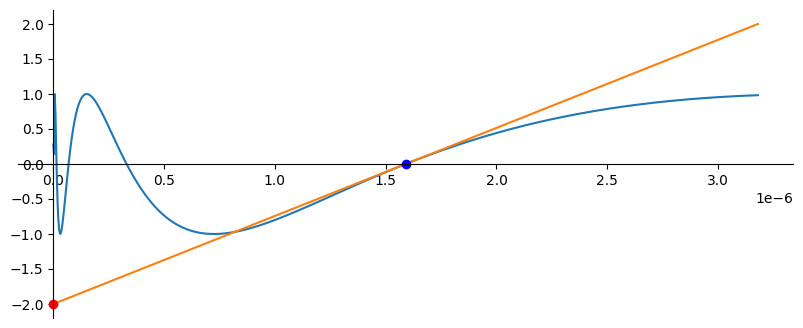

In [36]:
k = 9
fig, ax = plt.subplots(figsize=(10,4))
xs = np.linspace(10**(-k-3),2*a[k],1000)
ax.plot(xs, f(xs))
ax.plot(xs, m[k] * (xs - a[k]))
ax.plot([a[k]],[0],'bo')
ax.plot([0],[2 * (-1)**k],'ro')
fix_axes(ax)
